# 02 · Financing mix (Q2)

**Question (docs/01 §3, Q2).** How much of the market is financed, bank mortgage vs not bank-financed at registration, and off-plan vs ready? Has that shifted with interest rates?

**Definitions (docs/01 §4).**
- *Purchase-mortgage share of ready sales* (headline) = ready market sales matched to a Mortgage Registration (or Delayed Mortgage) of the same unit on the same day ÷ ready market sales. The register doesn't link a sale to its loan: a mortgaged purchase registers **both** a sale and a mortgage line, and new mortgages also include refinancing, so the old "mortgages ÷ (mortgages + sales)" double-counted. The match is a **lower bound**, because a loan registered on another day or keyed differently isn't matched.
- *Upper bound* = all Mortgage Registration / Delayed Mortgage lines ÷ ready market sales. It includes refinancing and loans on units bought earlier. The true share lies between the two.
- *New mortgages per 100 market sales* (secondary) = all individual new mortgages, including off-plan pre-registration and refinancing.
- Off-plan buyers mostly pay developers in instalments, so a sale without a mortgage is **not bank-financed at registration**, not necessarily a cash purchase.
- *Portfolio mortgages* (one loan over several units) are outside all of these and shown separately, counted once per deal.
- *Off-plan share* = off-plan market sales ÷ market sales, by count and by value.
- *Observed LTV* = loan ÷ price on the matched pairs.

**Rates.** EIBOR is not loaded yet, so the effective **Fed Funds** rate stands in (the AED is pegged to the USD). Correlations are associations, not causal effects.

**Scope.** 2004-01-01 to 2026-09-25; **2026 is partial**. As notebook 01 shows, 2004–2010 volumes are distorted by registration timing, so rate comparisons start in 2010.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from dubai_property import config
from dubai_property.analysis import common
from dubai_property.analysis import financing as fi
from dubai_property.analysis import market_cycles as mc
from dubai_property.analysis import plotting as P

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SNAP = common.snapshot_date()
START = config.REPORT_SCOPE_START
print("Data snapshot:", SNAP)

Data snapshot: 2026-09-25


## 1. How many ready purchases are bank-financed?

`financing.mortgage_indicators_monthly` / `mortgage_indicators_by_year`. The match rate is matched pairs ÷ all Mortgage Registration / Delayed Mortgage lines. It rose over time, so part of the lower bound's rise is better matching, not more borrowing.

In [2]:
mi = fi.mortgage_indicators_monthly(START, SNAP)
yearly_mi = fi.mortgage_indicators_by_year(mi)
corr = fi.share_rate_correlation(mi, from_year=2010)
print({k: round(v, 3) for k, v in corr.items()})
display(
    yearly_mi.set_index("year").loc[
        2010:,
        [
            "ready_sales",
            "purchase_mortgages",
            "purchase_share",
            "upper_share",
            "match_rate",
            "new_per_100_sales",
            "fed_funds_avg",
        ],
    ]
)

{'months': 200.0, 'corr_levels': 0.723, 'corr_12m_changes': -0.217}


,ready_sales,purchase_mortgages,purchase_share,upper_share,match_rate,new_per_100_sales,fed_funds_avg
year,,,,,,,
2010,"20,005.000","1,779.000",0.089,0.328,0.271,24.221,0.002
2011,"22,271.000","1,551.000",0.070,0.249,0.280,24.193,0.001
2012,"28,745.000","1,877.000",0.065,0.165,0.396,16.131,0.001
2013,"46,497.000","2,735.000",0.059,0.166,0.354,13.912,0.001
2014,"36,516.000","2,240.000",0.061,0.214,0.286,16.123,0.001
2015,"24,989.000","1,910.000",0.076,0.346,0.221,23.673,0.001
2016,"22,086.000","2,330.000",0.105,0.413,0.255,26.705,0.004
2017,"21,004.000","3,014.000",0.143,0.496,0.289,26.019,0.010
2018,"14,853.000","2,591.000",0.174,0.633,0.276,33.529,0.018


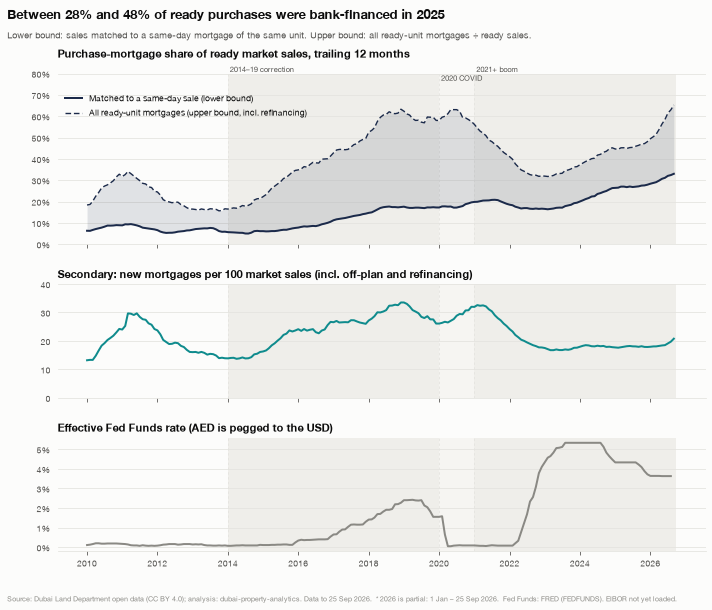

In [3]:
m = mi[mi["month"] >= "2010-01-01"]
fig, (a1, a2, a3) = P.figure(
    3, 1, size=(10, 8.4), sharex=True, gridspec_kw={"height_ratios": [3, 2, 2]}
)
fig.subplots_adjust(top=0.88, bottom=0.09, hspace=0.3)
for ax in (a1, a2, a3):
    P.shade_phases(
        ax, [p for p in mc.CYCLE_PHASES if p.start_year >= 2010], SNAP, by="month", label=ax is a1
    )
a1.fill_between(
    m["month"],
    m["purchase_share_12m"],
    m["upper_share_12m"],
    color=P.SERIES["total"],
    alpha=0.12,
    lw=0,
)
a1.plot(
    m["month"],
    m["purchase_share_12m"],
    color=P.SERIES["total"],
    lw=2,
    label="Matched to a same-day sale (lower bound)",
)
a1.plot(
    m["month"],
    m["upper_share_12m"],
    color=P.SERIES["total"],
    lw=1.4,
    ls=(0, (4, 2)),
    label="All ready-unit mortgages (upper bound, incl. refinancing)",
)
P.pct_axis(a1)
a1.set_ylim(0, 0.8)
a1.set_title("Purchase-mortgage share of ready market sales, trailing 12 months", pad=16)
a1.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
a2.plot(m["month"], m["new_per_100_sales_12m"], color=P.SERIES["third"], lw=2)
a2.set_ylim(0, 40)
a2.set_title("Secondary: new mortgages per 100 market sales (incl. off-plan and refinancing)")
a3.plot(m["month"], m["fed_funds_rate"], color=P.SERIES["neutral"], lw=2)
P.pct_axis(a3, decimals=0)
a3.set_title("Effective Fed Funds rate (AED is pegged to the USD)")
y25 = yearly_mi.set_index("year").loc[SNAP.year - 1]
P.titled(
    fig,
    f"Between {y25['purchase_share']:.0%} and {y25['upper_share']:.0%} of ready purchases were bank-financed in {SNAP.year - 1}",
    "Lower bound: sales matched to a same-day mortgage of the same unit. Upper bound: all ready-unit mortgages ÷ ready sales.",
)
P.add_source(fig, SNAP, note="Fed Funds: FRED (FEDFUNDS). EIBOR not yet loaded.")
P.save(fig, "q2_purchase_mortgage_share_vs_fedfunds")
plt.show()

## 2. Off-plan share of market sales

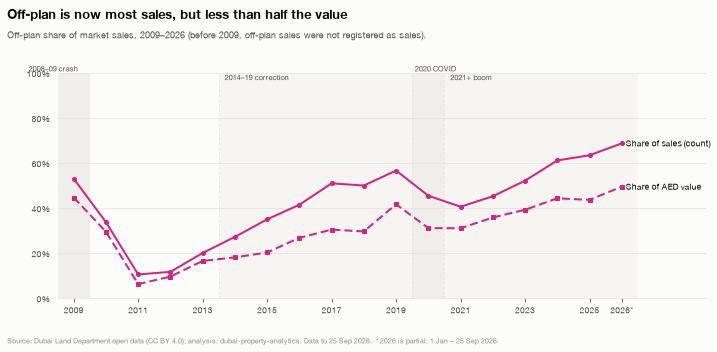

In [4]:
yearly = mc.sales_by_year(START, SNAP)
fig, ax = P.figure(size=(10, 4.8))
P.shade_phases(ax, mc.CYCLE_PHASES, SNAP)
y = yearly[yearly["year"] >= 2009]
ax.plot(y["year"], y["offplan_share_count"], color=P.SERIES["offplan"], marker="o", ms=4)
ax.plot(
    y["year"], y["offplan_share_value"], color=P.SERIES["offplan"], ls=(0, (4, 2)), marker="s", ms=4
)
last = y.iloc[-1]
P.direct_label(ax, last["year"], last["offplan_share_count"], "Share of sales (count)")
P.direct_label(ax, last["year"], last["offplan_share_value"], "Share of AED value")
P.pct_axis(ax)
ax.set_ylim(0, 1)
ax.set_xlim(2008.5, SNAP.year + 2.6)
P.year_ticks(ax, y["year"], SNAP)
P.titled(
    fig,
    "Off-plan is now most sales, but less than half the value",
    "Off-plan share of market sales, 2009–2026 (before 2009, off-plan sales were not registered as sales).",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_offplan_share_count_value")
plt.show()

## 3. Observed loan-to-value (LTV) by year

A same-day mortgage and sale of the same unit, keyed on date, area, building, project, sq m, rooms, type and sub-type, and unique on both sides. The mass of the distribution sits at the regulatory caps, which is what showed in Phase 1 that `actual_worth` on these mortgage rows is the loan amount.

In [5]:
ltv = fi.ltv_by_year()
display(ltv.set_index("year"))

,pairs,p25,median,p75,share_at_0_75,share_at_0_80,share_at_0_848,share_0_80_to_1,share_above_1
year,,,,,,,,,
2004,139,0.628,0.750,1.000,0.036,0.029,0.000,0.230,0.173
2005,156,0.660,0.791,1.000,0.071,0.032,0.000,0.250,0.218
2006,291,0.683,0.781,1.000,0.014,0.038,0.000,0.265,0.168
2007,812,0.678,0.800,0.900,0.044,0.095,0.000,0.267,0.155
2008,1751,0.713,0.840,1.093,0.038,0.072,0.002,0.266,0.279
2009,1583,0.702,0.807,0.997,0.066,0.071,0.001,0.259,0.243
2010,1779,0.700,0.800,0.924,0.064,0.083,0.001,0.241,0.214
2011,1551,0.699,0.790,0.850,0.075,0.143,0.001,0.224,0.121
2012,1877,0.700,0.776,0.808,0.087,0.198,0.002,0.150,0.099


### The April 2020 rule change

CBUAE Board Resolution 31/2/2020 (effective **8 April 2020**) amended Art. 3(2) of the Regulations Regarding Mortgage Loans and raised the first-home caps for homes up to AED 5M by 5 points: **expatriates 75% → 80%, UAE nationals 80% → 85%** (`seed_ltv_rules`, verified against the CBUAE rulebook). Monthly shares of matched loans at each cap around the change (`financing.ltv_cluster_shares_monthly`):

In [6]:
clusters = fi.ltv_cluster_shares_monthly("2019-10-01", "2020-12-31")
display(clusters.set_index(clusters["month"].dt.strftime("%Y-%m")).drop(columns="month"))

,pairs,share_at_0_75,share_at_0_80,share_at_0_848,share_0_845_to_0_855
month,,,,,
2019-10,254,0.343,0.236,0.000,0.004
2019-11,257,0.323,0.218,0.000,0.000
2019-12,226,0.336,0.265,0.004,0.004
2020-01,236,0.322,0.174,0.000,0.004
2020-02,258,0.333,0.240,0.004,0.004
2020-03,250,0.400,0.176,0.000,0.004
2020-04,40,0.575,0.150,0.025,0.025
2020-05,111,0.288,0.252,0.027,0.045
2020-06,167,0.132,0.222,0.078,0.156


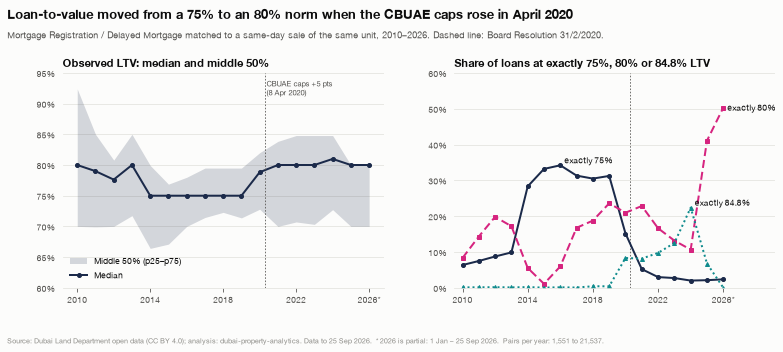

In [7]:
fig, (a1, a2) = P.figure(1, 2, size=(11, 4.8))
fig.subplots_adjust(top=0.8, bottom=0.17, wspace=0.22)
lt = ltv[ltv["year"] >= 2010]
a1.fill_between(
    lt["year"],
    lt["p25"],
    lt["p75"],
    color=P.SERIES["total"],
    alpha=0.18,
    lw=0,
    label="Middle 50% (p25–p75)",
)
a1.plot(lt["year"], lt["median"], color=P.SERIES["total"], marker="o", ms=4, label="Median")
a1.set_ylim(0.6, 0.95)
a1.set_title("Observed LTV: median and middle 50%")
P.pct_axis(a1)
a1.legend(loc="lower left")
P.year_ticks(a1, lt["year"], SNAP, step=4)
for ax in (a1, a2):
    ax.axvline(2020 + 98 / 366, color=P.TEXT_2, lw=0.8, ls=(0, (2, 2)))
a1.text(
    2020 + 98 / 366,
    0.94,
    " CBUAE caps +5 pts\n (8 Apr 2020)",
    fontsize=7.5,
    color=P.TEXT_2,
    va="top",
)
a2.plot(lt["year"], lt["share_at_0_75"], color=P.SERIES["ready"], marker="o", ms=4)
a2.plot(
    lt["year"], lt["share_at_0_80"], color=P.SERIES["offplan"], marker="s", ms=4, ls=(0, (4, 2))
)
a2.plot(
    lt["year"], lt["share_at_0_848"], color=P.SERIES["third"], marker="^", ms=4, ls=(0, (1, 1.5))
)
P.direct_label(
    a2, 2024, lt.set_index("year").loc[2024, "share_at_0_848"], "exactly 84.8%", va="bottom"
)
P.direct_label(
    a2, 2016, lt.set_index("year").loc[2016, "share_at_0_75"], "exactly 75%", va="bottom"
)
P.direct_label(a2, lt["year"].iloc[-1], lt["share_at_0_80"].iloc[-1], "exactly 80%")
P.pct_axis(a2)
a2.set_ylim(0, 0.6)
a2.set_xlim(2009.5, SNAP.year + 3.2)
a2.set_title("Share of loans at exactly 75%, 80% or 84.8% LTV")
P.year_ticks(a2, lt["year"], SNAP, step=4)
P.titled(
    fig,
    "Loan-to-value moved from a 75% to an 80% norm when the CBUAE caps rose in April 2020",
    "Mortgage Registration / Delayed Mortgage matched to a same-day sale of the same unit, 2010–2026. Dashed line: Board Resolution 31/2/2020.",
)
P.add_source(fig, SNAP, note=f"Pairs per year: {lt['pairs'].min():,} to {lt['pairs'].max():,}.")
P.save(fig, "q2_ltv_by_year")
plt.show()

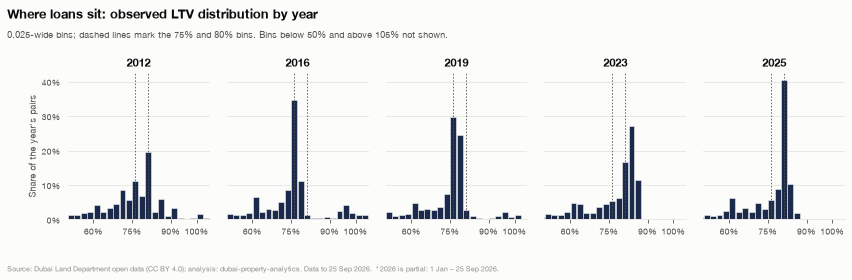

In [8]:
years = [2012, 2016, 2019, 2023, 2025]
hist = fi.ltv_histogram(years)
fig, axes = P.figure(1, len(years), size=(12, 3.8), sharey=True)
fig.subplots_adjust(top=0.74, bottom=0.2, wspace=0.12)
for ax, yr in zip(axes, years, strict=True):
    h = hist[(hist["year"] == yr) & hist["bucket"].between(1, 28)]
    ax.bar(
        h["ltv_low"] + 0.0125,
        h["share"],
        width=0.023,
        color=P.SERIES["total"],
        edgecolor=P.SURFACE,
        lw=0.5,
    )
    for cap in (0.75, 0.80):
        ax.axvline(cap + 0.0125, color=P.TEXT_2, lw=0.8, ls=(0, (2, 2)))
    ax.set_title(P.year_label(yr, SNAP), loc="center")
    ax.set_xlim(0.5, 1.05)
    ax.set_xticks([0.6, 0.75, 0.9, 1.0])
    ax.set_xticklabels(["60%", "75%", "90%", "100%"])
    ax.grid(False, axis="x")
P.pct_axis(axes[0])
axes[0].set_ylabel("Share of the year's pairs")
P.titled(
    fig,
    "Where loans sit: observed LTV distribution by year",
    "0.025-wide bins; dashed lines mark the 75% and 80% bins. Bins below 50% and above 105% not shown.",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_ltv_distribution_by_year")
plt.show()

## 4. Portfolio mortgages (shown separately)

One registration over several units, often a developer's or an investor's loan. They are **not** in the mortgage share. Deals are counted once and value once per deal (C16). The value is as registered and is not a verified loan amount (C10).

,portfolio_deals,portfolio_lines,portfolio_value_aed,new_mortgages,new_mortgage_loans_aed
year,,,,,
2004,0.000,0.000,0.000,"1,159.000","7,654,294,152.000"
2005,0.000,0.000,0.000,"1,249.000","12,888,827,219.000"
2006,0.000,0.000,0.000,"1,640.000","36,609,078,905.000"
2007,4.000,9.000,"10,712,270,000.000","2,737.000","36,373,860,546.000"
2008,1.000,1.000,"1,928,864,375.000","5,218.000","74,765,712,904.000"
2009,5.000,5.000,"13,609,890,032.000","7,022.000","18,324,081,170.000"
2010,4.000,4.000,"4,610,925,000.000","7,311.000","26,430,337,580.000"
2011,4.000,6.000,"9,549,650,854.000","6,022.000","31,865,116,949.000"
2012,8.000,8.000,"9,933,178,251.000","5,250.000","17,639,484,288.000"


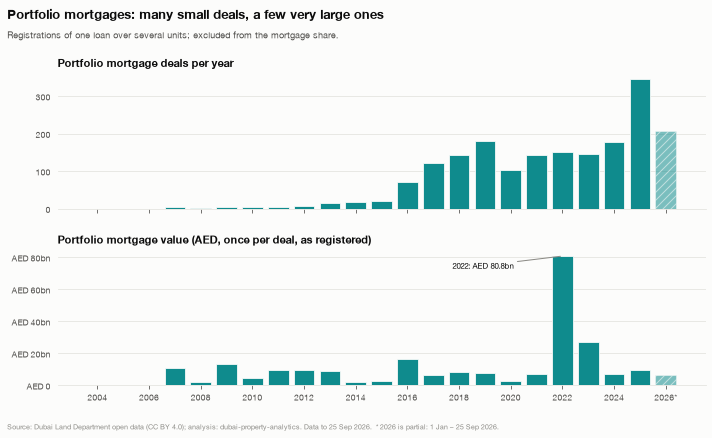

In [9]:
port = fi.portfolio_by_year(START, SNAP)
display(port.set_index("year"))
fig, (a1, a2) = P.figure(2, 1, size=(10, 6), sharex=True)
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.3)
P.year_bars(a1, port["year"], port["portfolio_deals"], SNAP, P.SERIES["third"])
a1.set_title("Portfolio mortgage deals per year")
P.count_axis(a1)
P.year_bars(a2, port["year"], port["portfolio_value_aed"], SNAP, P.SERIES["third"])
a2.set_title("Portfolio mortgage value (AED, once per deal, as registered)")
P.aed_axis(a2, prefix=True)
P.year_ticks(a2, port["year"], SNAP)
top = port.loc[port["portfolio_value_aed"].idxmax()]
a2.annotate(
    f"{int(top['year'])}: {P.fmt_aed(top['portfolio_value_aed'])}",
    (top["year"], top["portfolio_value_aed"]),
    xytext=(-110, -5),
    textcoords="offset points",
    fontsize=8,
    va="top",
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
P.titled(
    fig,
    "Portfolio mortgages: many small deals, a few very large ones",
    "Registrations of one loan over several units; excluded from the mortgage share.",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_portfolio_mortgages")
plt.show()

## Findings

1. **Between about 28% and 48% of ready purchases were bank-financed in 2025.** 21,537 of 77,154 ready market sales (27.9%) are matched to a same-day purchase mortgage of the same unit. That is the lower bound. All Mortgage Registration / Delayed Mortgage lines, which include refinancing, come to 48.1% of ready sales, the upper bound. The matched share rose from 5.9% (2013) to 19.5% (2023) and 27.9% (2025). But the match rate (matched ÷ all ready-unit mortgages) also rose, from 22–40% before 2020 to 58% in 2024–25, so much of that rise is better matching, not only more borrowing. In 2026 to date both bounds jump (33.7% / 70.2%) because ready sales fell 37% while mortgage registrations held (23,306 in Jan–Aug vs 24,430). The secondary indicator, new mortgages per 100 market sales, has been flat at about 18 since 2022 (17.9 in 2025) against 26–34 in 2016–2020, because the market has shifted to off-plan.
2. **Rates explain little of the mortgage share.** Since 2010 the trailing-12-month matched share and the Fed Funds rate correlate at +0.72 in levels, but that is two series trending up together in 2022–25. In 12-month changes the correlation is −0.22. Rate cuts in 2020 and rate rises in 2022–23 both coincided with a steady or rising matched share. Sales without a matched mortgage are **not bank-financed at registration**, not necessarily cash: most are off-plan purchases paid to the developer in instalments. (Fed Funds stands in for EIBOR, which is not loaded; this is an association only.)
3. **Off-plan is most sales but not most value.** The off-plan share of market sales rose from 40.6% by count (31.0% by value) in 2021 to 63.4% (43.6%) in 2025, and to 68.7% (49.5%) in 2026 to date.
4. **Observed LTVs follow the CBUAE caps, and moved when the caps changed in April 2020.** The median loan ÷ same-day price was exactly 0.75 every year 2014–2019, with 28–34% of loans at exactly 75%: the expatriate first-home cap (≤ AED 5M) under Circular No. 31/2013. CBUAE Board Resolution 31/2/2020 (effective 8 April 2020) raised that cap to 80% and the UAE-national cap from 80% to 85%. From 2021 the median is 0.80, and 41.1% (2025) and 50.3% (2026) of loans sit at exactly 80%. The shift is visible within weeks: loans at exactly 75% were 32–40% of monthly pairs from October 2019 to March 2020, and 7–10% from July 2020. A second cluster at exactly **84.8%**, absent before April 2020, appeared from April–June 2020 (10–14% of monthly pairs from July), peaked at 22.4% of 2024 pairs, and is 0.0% in 2026. Its timing is **consistent with** the national first-home cap rising to 85%, but nationality isn't in the data, so this is not proven. Why the loans sit at 84.8% rather than 85%, and why the cluster vanishes in 2026, is not explained by the rules.
5. **Portfolio mortgages are lumpy and kept separate.** There have been 1,873 deals worth AED 245.0bn (once per deal) since 2004. 2022 alone had AED 80.8bn across 151 deals. Counted in the share, a handful of deals would swing it.